# Kaggle Dataset Analysis

This notebook downloads a dataset directly from Kaggle, loads it with pandas, and runs a starter exploratory analysis.

## 1. Environment

Recommended setup from the project root:

```bash
python3 -m venv .venv
.venv/bin/python -m pip install -r requirements.txt
.venv/bin/python -m ipykernel install --user --name ai-job-impact-analysis --display-name "AI Job Impact Analysis"
.venv/bin/jupyter lab
```

The dataset is downloaded with `kagglehub`. If authentication is required, run KaggleHub's login flow or configure your Kaggle credentials before running the download cell. Downloaded data is stored under `data/kagglehub`, which is ignored by git.

## 2. Imports and Configuration

In [1]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
MPLCONFIGDIR = PROJECT_ROOT / ".matplotlib"
KAGGLEHUB_CACHE = PROJECT_ROOT / "data" / "kagglehub"

MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
KAGGLEHUB_CACHE.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))
os.environ.setdefault("KAGGLEHUB_CACHE", str(KAGGLEHUB_CACHE))

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

KAGGLE_DATASET = "muhammadwaqas023/ai-impact-in-future-on-jobs-market-in-2030"

SUPPORTED_EXTENSIONS = {".csv", ".xlsx", ".xls", ".json", ".parquet"}

Matplotlib is building the font cache; this may take a moment.


## 3. Download from Kaggle

In [2]:
dataset_path = Path(kagglehub.dataset_download(KAGGLE_DATASET))

print("Path to dataset files:", dataset_path)

downloaded_files = sorted(
    path for path in dataset_path.rglob("*") if path.is_file() and path.suffix.lower() in SUPPORTED_EXTENSIONS
)

downloaded_files

100%|██████████| 106k/106k [00:02<00:00, 42.3kB/s]

Extracting files...
Path to dataset files: /Users/nicke/Documents/local-repo/AI-job-impact-analysis/data/kagglehub/datasets/muhammadwaqas023/ai-impact-in-future-on-jobs-market-in-2030/versions/1


[PosixPath('/Users/nicke/Documents/local-repo/AI-job-impact-analysis/data/kagglehub/datasets/muhammadwaqas023/ai-impact-in-future-on-jobs-market-in-2030/versions/1/AI_Impact_on_Jobs_2030.csv')]

## 4. Load Data

In [3]:
def load_dataset(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()

    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if suffix == ".json":
        return pd.read_json(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)

    raise ValueError(f"Unsupported file type: {suffix}")


if not downloaded_files:
    raise FileNotFoundError(f"No supported data files found in {dataset_path}")

# If Kaggle downloads multiple data files, choose the one to analyze here.
DATA_FILE = downloaded_files[0]
print(f"Loading: {DATA_FILE}")

df = load_dataset(DATA_FILE)
df.head()

Loading: /Users/nicke/Documents/local-repo/AI-job-impact-analysis/data/kagglehub/datasets/muhammadwaqas023/ai-impact-in-future-on-jobs-market-in-2030/versions/1/AI_Impact_on_Jobs_2030.csv


,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


## 5. Basic Structure

In [4]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.info()

Rows: 3,000
Columns: 20
<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              3000 non-null   str    
 1   Job_Title                3000 non-null   str    
 2   Industry                 3000 non-null   str    
 3   Country                  3000 non-null   str    
 4   Education_Level          3000 non-null   str    
 5   Years_Experience         3000 non-null   int64  
 6   AI_Replacement_Risk      3000 non-null   float64
 7   Future_Demand_Score      3000 non-null   float64
 8   Remote_Work_Possibility  3000 non-null   str    
 9   Average_Salary_USD       3000 non-null   int64  
 10  Required_Skills          3000 non-null   str    
 11  Automation_Level         3000 non-null   str    
 12  Job_Growth_2030          3000 non-null   int64  
 13  Work_Hours_Per_Week      3000 non-null   int64  
 14  Company_Siz

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Employee_ID,3000,3000,AIJ-100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job_Title,3000,20,Software Developer,164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industry,3000,10,Energy,335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,3000,10,UAE,347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,3000,4,Bachelor,782,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years_Experience,3000.0,NaN,NaN,NaN,12.383,7.528958,0.0,6.0,12.0,19.0,25.0
AI_Replacement_Risk,3000.0,NaN,NaN,NaN,0.50291,0.261293,0.05,0.28,0.5,0.73,0.95
Future_Demand_Score,3000.0,NaN,NaN,NaN,0.601203,0.226674,0.2,0.42,0.6,0.8,0.99
Remote_Work_Possibility,3000,3,Hybrid,1011,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Average_Salary_USD,3000.0,NaN,NaN,NaN,126641.746667,55405.053057,30221.0,77262.0,127660.5,174811.75,219998.0


## 6. Data Quality Checks

In [6]:
missing = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: x["missing_count"] / len(df) * 100)
    .sort_values("missing_pct", ascending=False)
)

missing[missing["missing_count"] > 0]

,missing_count,missing_pct


In [7]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


In [8]:
unique_counts = df.nunique(dropna=False).sort_values(ascending=False)
unique_counts.to_frame("unique_values")

,unique_values
Employee_ID,3000
Average_Salary_USD,2970
Required_Skills,2937
Job_Satisfaction,401
Performance_Score,301
AI_Replacement_Risk,91
Future_Demand_Score,80
Job_Growth_2030,56
Work_Hours_Per_Week,31
Years_Experience,26


## 7. Exploratory Analysis

In [9]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Years_Experience', 'AI_Replacement_Risk', 'Future_Demand_Score', 'Average_Salary_USD', 'Job_Growth_2030', 'Work_Hours_Per_Week', 'Performance_Score', 'Job_Satisfaction']
Categorical columns: ['Employee_ID', 'Job_Title', 'Industry', 'Country', 'Education_Level', 'Remote_Work_Possibility', 'Required_Skills', 'Automation_Level', 'Company_Size', 'AI_Tool_Usage', 'Upskilling_Needed', 'Hiring_Trend_2026']


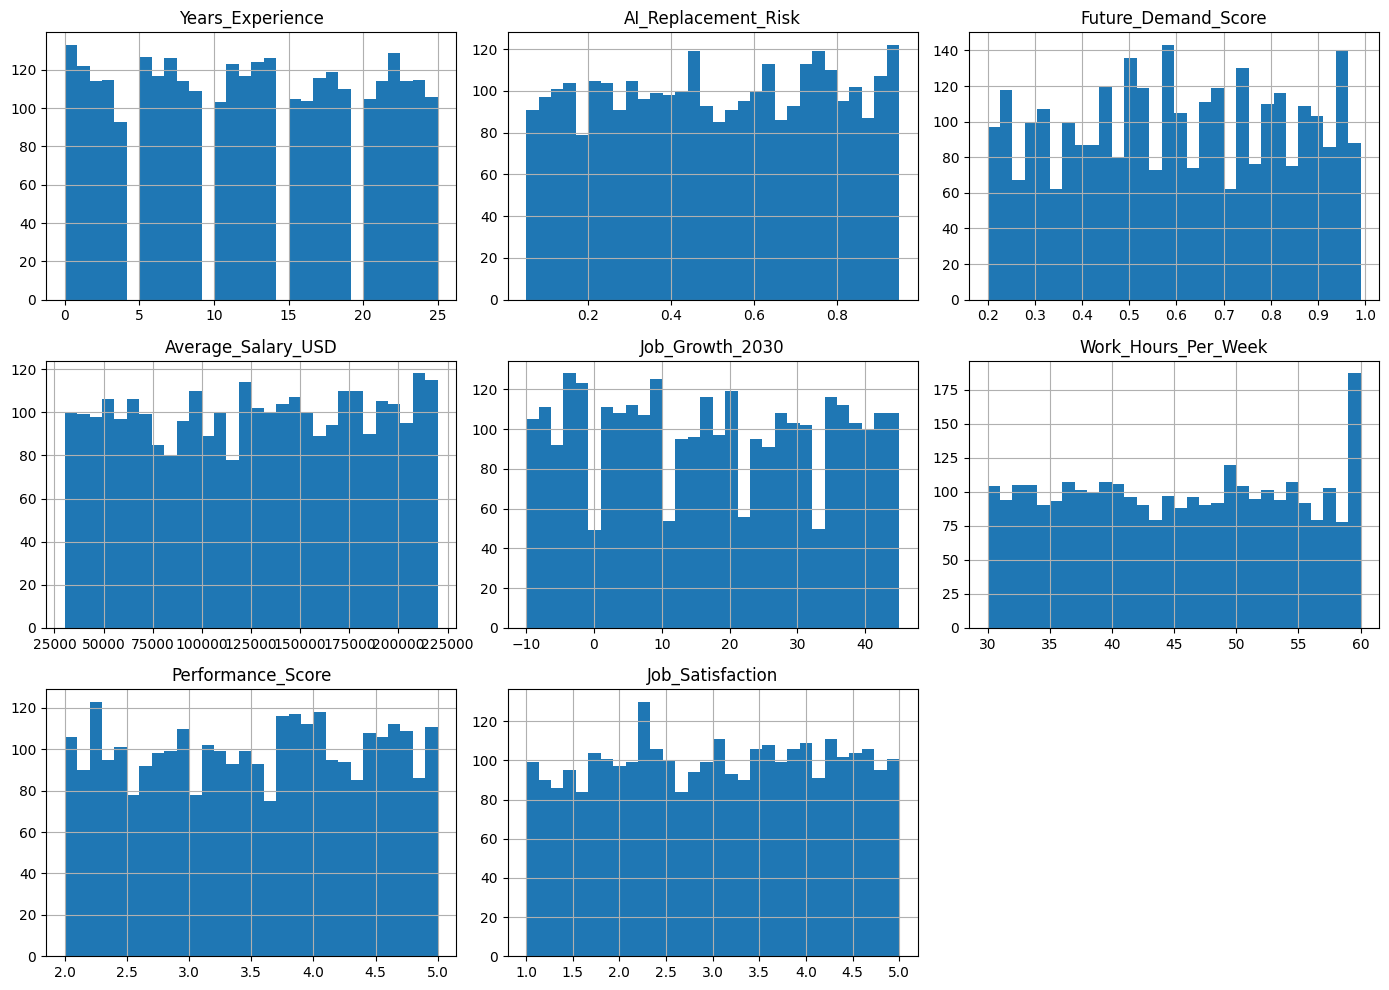

In [10]:
if numeric_cols:
    df[numeric_cols].hist(figsize=(14, 10), bins=30)
    plt.tight_layout()
else:
    print("No numeric columns found.")

In [11]:
for col in categorical_cols[:10]:
    display(df[col].value_counts(dropna=False).head(20).to_frame("count"))

,count
Employee_ID,
AIJ-100000,1
AIJ-100001,1
AIJ-100002,1
AIJ-100003,1
AIJ-100004,1
AIJ-100005,1
AIJ-100006,1
AIJ-100007,1
AIJ-100008,1


,count
Job_Title,
Software Developer,164
HR Specialist,163
Cybersecurity Analyst,162
Robotics Engineer,162
UX Designer,158
Machine Learning Engineer,157
Product Manager,157
Blockchain Developer,155
Teacher,153


,count
Industry,
Energy,335
Government,323
Finance,310
Manufacturing,303
Education,300
Transportation,293
Technology,291
Media,287
Retail,285


,count
Country,
UAE,347
Germany,318
Australia,312
Pakistan,300
Japan,299
UK,298
USA,295
Canada,285
India,279


,count
Education_Level,
Bachelor,782
PhD,779
High School,727
Master,712


,count
Remote_Work_Possibility,
Hybrid,1011
Yes,1003
No,986


,count
Required_Skills,
"Cloud Computing, Kubernetes, Leadership",3
"Communication, PyTorch, Excel",3
"AWS, Azure, Excel",2
"Leadership, PyTorch, TensorFlow",2
"TensorFlow, Excel, Communication",2
"Machine Learning, Leadership, Project Management",2
"Data Visualization, Deep Learning, Kubernetes",2
"Python, Deep Learning, SQL",2
"Data Visualization, Docker, Leadership, Excel",2


,count
Automation_Level,
Low,1037
Medium,1011
High,952


,count
Company_Size,
Medium,1025
Enterprise,990
Startup,985


,count
AI_Tool_Usage,
Low,1033
High,1014
Moderate,953


,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Job_Growth_2030,Work_Hours_Per_Week,Performance_Score,Job_Satisfaction
Years_Experience,1.000000,-0.033668,-0.047494,0.012795,-0.023781,-0.010387,0.023758,0.018071
AI_Replacement_Risk,-0.033668,1.000000,0.007761,-0.006714,0.004887,0.001582,-0.012806,0.016181
Future_Demand_Score,-0.047494,0.007761,1.000000,0.005162,0.054455,-0.004530,0.018239,0.012901
Average_Salary_USD,0.012795,-0.006714,0.005162,1.000000,-0.011723,-0.012034,-0.009519,0.017736
Job_Growth_2030,-0.023781,0.004887,0.054455,-0.011723,1.000000,0.001496,-0.011879,0.001757
Work_Hours_Per_Week,-0.010387,0.001582,-0.004530,-0.012034,0.001496,1.000000,0.020974,0.014921
Performance_Score,0.023758,-0.012806,0.018239,-0.009519,-0.011879,0.020974,1.000000,-0.013037
Job_Satisfaction,0.018071,0.016181,0.012901,0.017736,0.001757,0.014921,-0.013037,1.000000


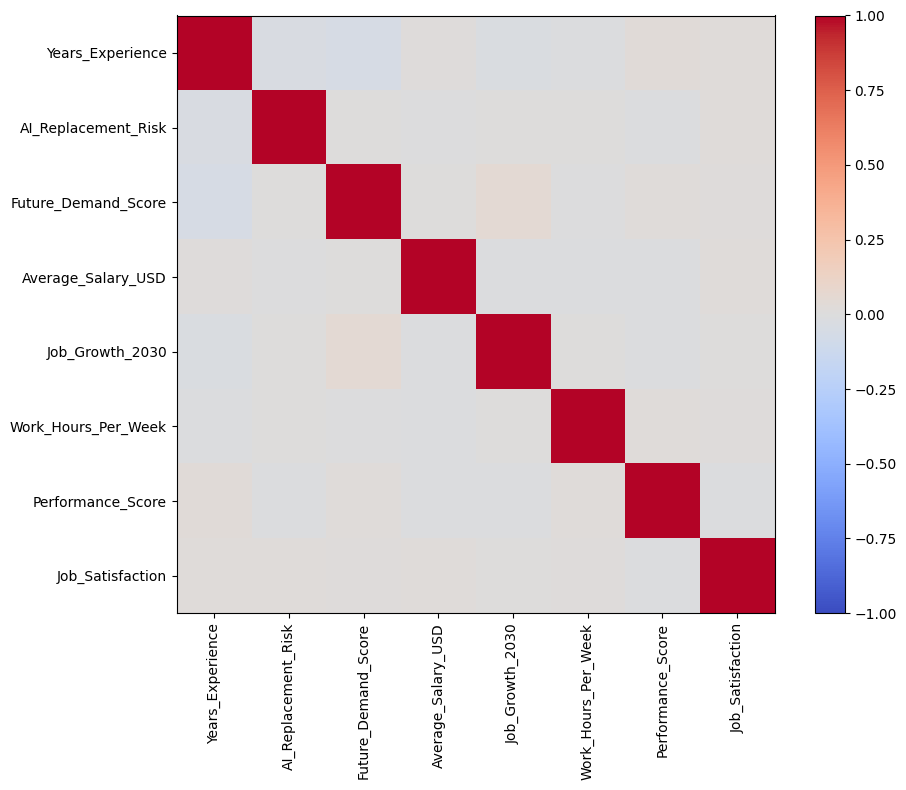

In [12]:
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr(numeric_only=True)
    display(corr)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=90)
    ax.set_yticks(range(len(corr.index)), corr.index)
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
else:
    print("Need at least two numeric columns for correlation analysis.")

## 8. Focused Questions

Add dataset-specific questions here, then create analysis cells below each question.

- What are the most important trends or patterns?
- Which variables appear related to the target outcome?
- Are there meaningful differences across groups?
- What data quality issues could affect conclusions?

In [13]:
# Example: replace with a dataset-specific grouping column and metric.
# df.groupby("category_column")["numeric_metric"].agg(["count", "mean", "median"]).sort_values("mean", ascending=False)

## 9. Findings

Summarize the main findings, caveats, and recommended next steps here.